# Задача 5. Обучение без учителя

## Задача

- [x] Найти данные с количеством признаков хотя бы 50, на которых можно решить задачу кластеризации.
- [x] Выполнить разведочный анализ (**EDA**). При необходимости выполнить полезные преобразования данных.
- [x] Самостоятельно реализуйте один из алгоритмов кластеризации, например **K-means**.
- [x] Обучите модели кластеризации, используя свою реализацию, а также хотя бы две реализации из **sklearn** (**KMeans**, **Affinity Propogation**, **DBSCAN** и тд).
- [x] При обучении использовать **подбор гиперпараметров**.
- [x] Сравнить качество моделей: замерить скорость обучения, вычислить различные метрики качества.
- [x] * (**+3 балла**) Также снизить размерность данных с помощью метода главных компонент **PCA** и и понять качество дальнейшей кластеризации всеми использованными реализациями при различном количестве главных компонент.
- [x] * (**+2 балла**) Визуализировать данные снижением размерности до 2 или 3 с помощью **PCA** и **t-SNE**. В случае проблем с производительностью **t-SNE**, можно сначала до какой то степени снизить размерность с помощью **PCA**, а затем запустить **t-SNE**.

## Датасет

В качестве датасета использован [Sign Language MNIST](https://www.kaggle.com/datasets/datamunge/sign-language-mnist) - набор изображений жестов американского жестового языка. Датасет содержит 784 признака (пиксели изображений 28×28) и 24 класса (буквы A–Y без J и Z, так как они требуют движения).

In [3]:
import pandas as pd
import numpy as np
import os
import kagglehub
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
%matplotlib inline

RANDOM_STATE = 42

dataset_path = kagglehub.dataset_download("datamunge/sign-language-mnist")

data_path = os.path.join(dataset_path, "sign_mnist_test.csv")
df = pd.read_csv(data_path)

df.head()

/home/maxim/ml-course/solutions/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,...,138,148,127,89,82,96,106,112,120,107
1,5,126,128,131,132,133,134,135,135,136,...,47,104,194,183,186,184,184,184,182,180
2,10,85,88,92,96,105,123,135,143,147,...,68,166,242,227,230,227,226,225,224,222
3,0,203,205,207,206,207,209,210,209,210,...,154,248,247,248,253,236,230,240,253,255
4,3,188,191,193,195,199,201,202,203,203,...,26,40,64,48,29,46,49,46,46,53


## EDA

Посмотрим на распределение классов.

In [4]:
X = df.drop(columns=["label"])
y = df["label"]

y.value_counts().sort_index()

label
0     331
1     432
2     310
3     245
4     498
5     247
6     348
7     436
8     288
10    331
11    209
12    394
13    291
14    246
15    347
16    164
17    144
18    246
19    248
20    266
21    346
22    206
23    267
24    332
Name: count, dtype: int64

In [5]:
df.shape

(7172, 785)

Датасет содержит 7172 примера.  
Распределение по классам относительно сбалансировано - от 144 до 498 примеров на класс, без явного доминирования отдельных категорий.

Визуализируем по одному примеру каждого класса, чтобы понять визуальную природу данных.

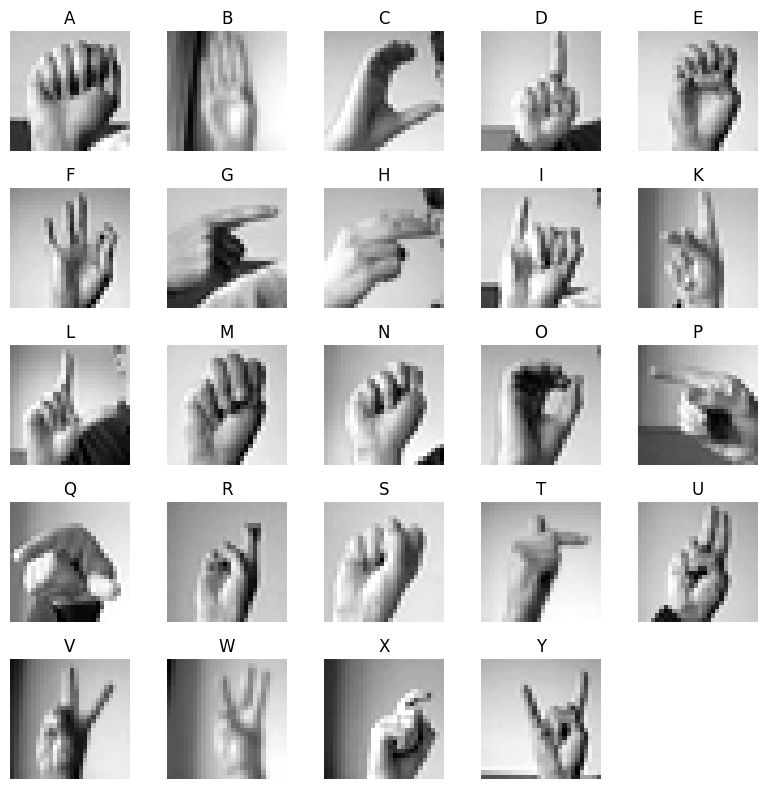

In [6]:
labels = sorted(df["label"].unique())
count = 1

plt.figure(figsize=(8, 8))

for label in labels:
    row = df[df["label"] == label]

    image = row.iloc[0].drop("label").values.reshape(28, 28)

    plt.subplot(5, 5, count)
    plt.imshow(image, cmap="gray")

    plt.title(chr(label + 65))
    plt.axis("off")

    count += 1

plt.tight_layout()

Видно, что некоторые жесты визуально похожи - например, A, E и S, или M, N и T.  
Это может затруднить кластеризацию, так как расстояния между соответствующими классами в пространстве пикселей будут небольшими.

### Визуализация с помощью `PCA`

Применим `PCA` для проекции данных на 2 главные компоненты, чтобы понять первичное представление структуры данных.

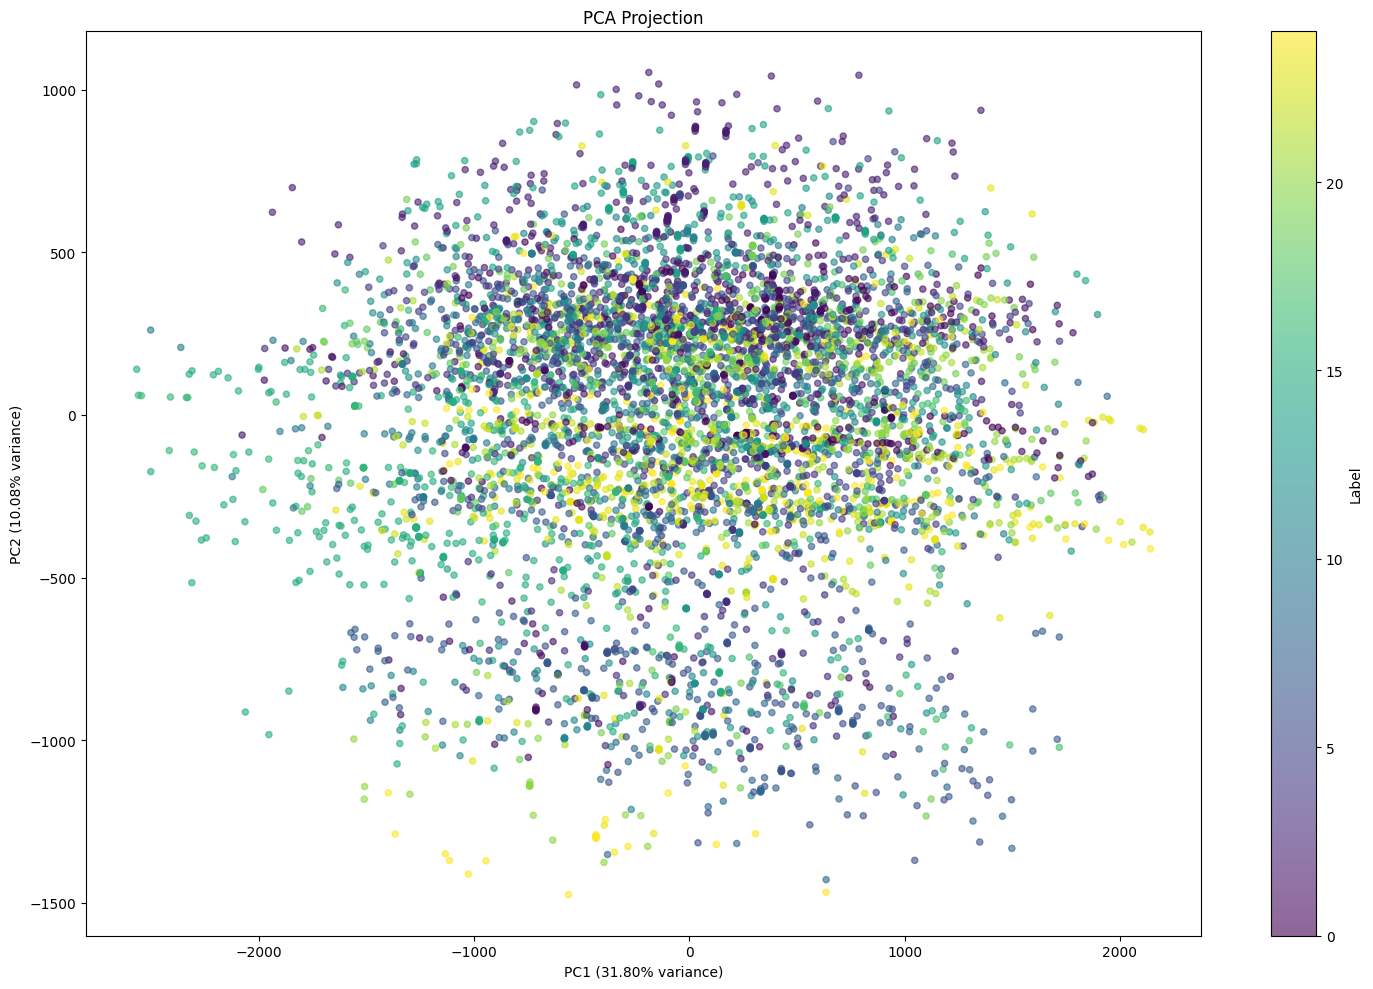

In [22]:
pca = PCA(random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(15, 10))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, alpha=0.6, s=20)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
plt.title("PCA Projection")

plt.colorbar(label="Label")
plt.tight_layout()

Первые две компоненты объясняют 31.8% и 10.08% дисперсии. В проекции кластеры сильно перекрываются - чёткого разделения нет, что подтверждает визуальную схожесть жестов.

### Выбор числа компонент `PCA`

Построим график накопленной объяснённой дисперсии, чтобы определить, до какой размерности можно сжать данные без существенных потерь.

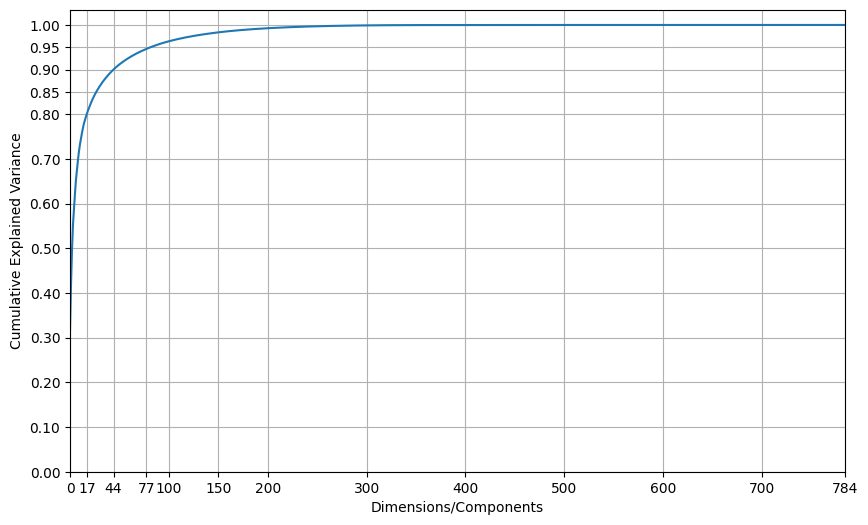

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Dimensions/Components")
plt.ylabel("Cumulative Explained Variance")
plt.yticks(np.concatenate([np.arange(0, 0.8, 0.1), np.arange(0.8, 1.05, 0.05)]))
plt.xticks([*plt.xticks()[0], 17, 44, 77, 150, 28 * 28])
plt.xlim(0, 28 * 28)
plt.grid(True)

График показывает:

- 17 компонент → ~80% дисперсии
- 44 компоненты → ~90% дисперсии
- 77 компонент → ~95% дисперсии
- 200 компонент → ~99% дисперсии

Эти значения и выбраны как контрольные точки для экспериментов - каждая соответствует значимому порогу сохранения информации (от умеренного до почти полного сохранения).

### Визуализация с помощью `t-SNE`

`t-SNE` оптимизирует расположение точек так, чтобы похожие точки оказывались рядом, что позволяет увидеть локальную структуру данных.  
Запустим `t-SNE` на исходных данных.

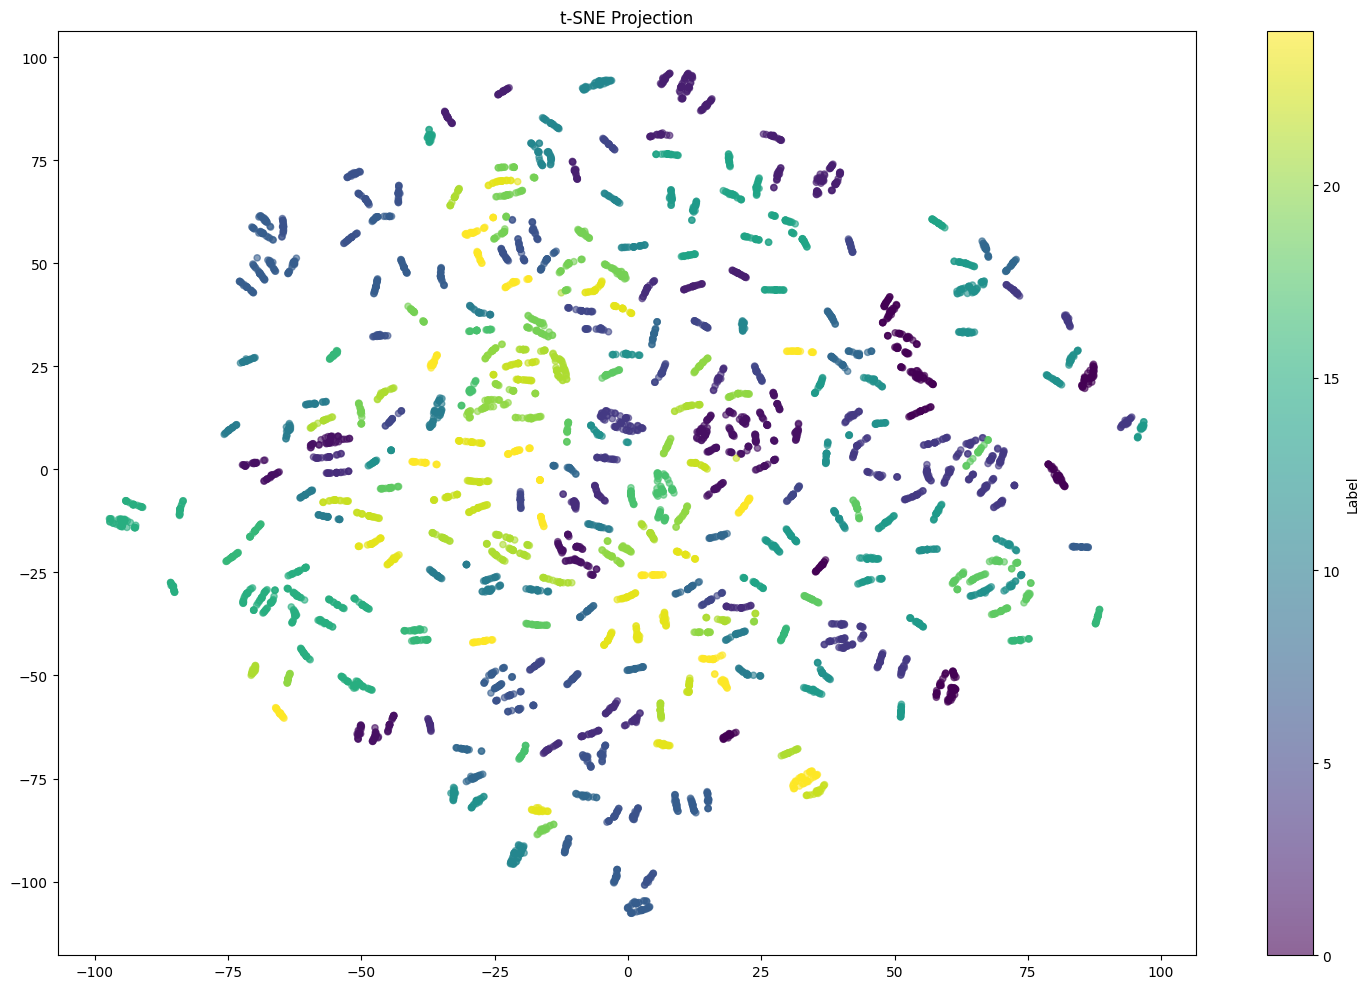

In [24]:
tsne = TSNE(random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(15, 10))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, alpha=0.6, s=20)

plt.title("t-SNE Projection")

plt.colorbar(label="Label")
plt.tight_layout()

`t-SNE` выявляет отдельные плотные группы, хотя полного разделения нет. Некоторые классы образуют несколько разрозненных групп - скорее всего, из-за различий в условиях съёмки или положении руки на фото.

Для улучшения качества визуализации и ускорения вычислений предварительно снизим размерность с помощью `PCA` до 77 компонент, а затем запустим `t-SNE` с увеличенным числом итераций.

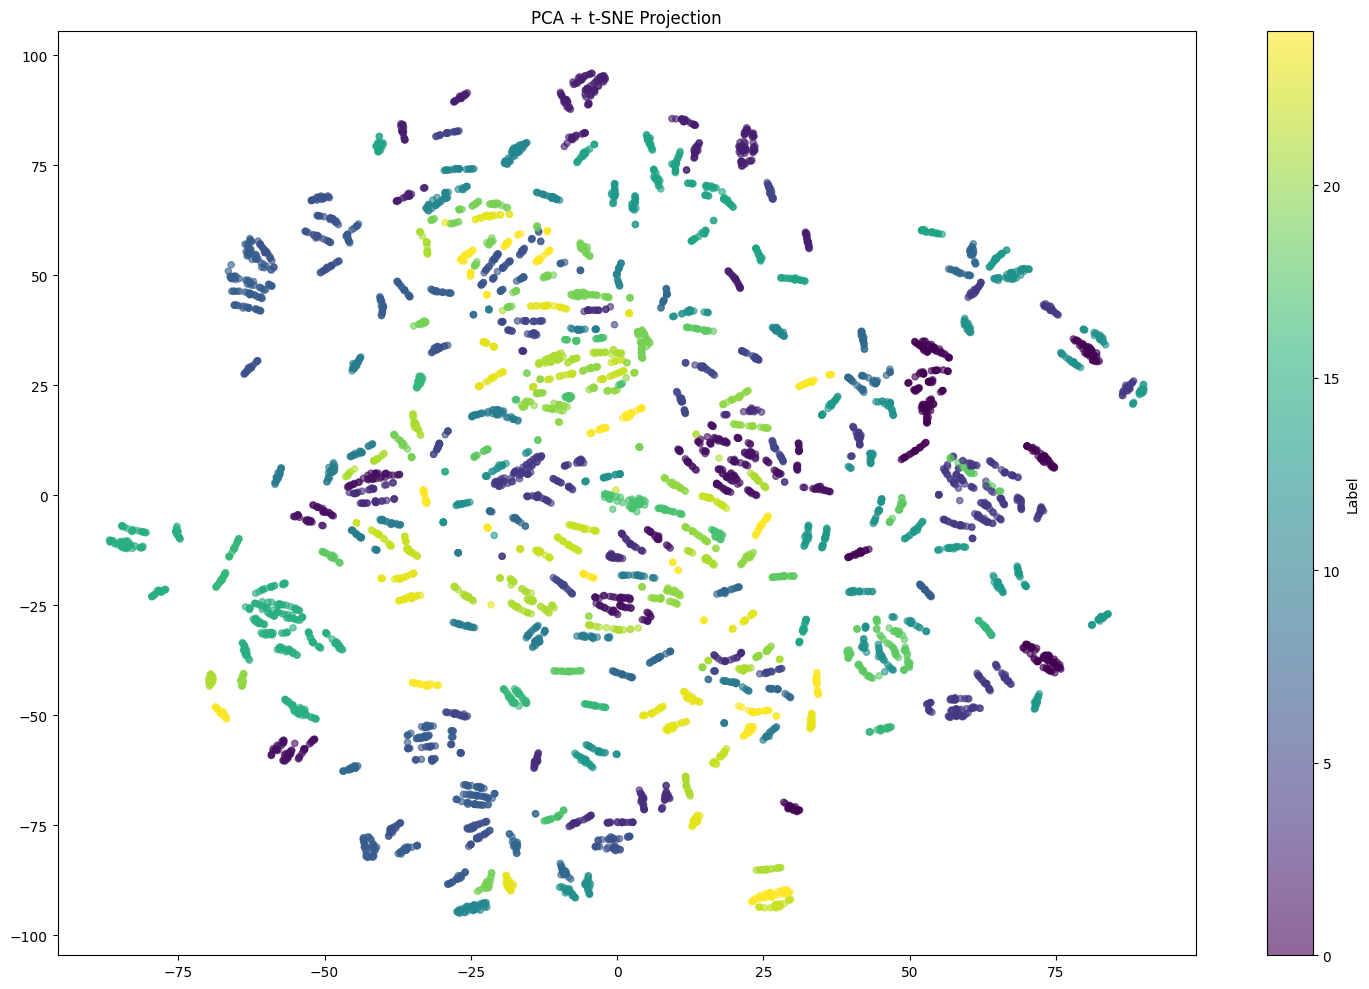

In [25]:
updated_pca = PCA(n_components=77, random_state=RANDOM_STATE)
X_updated_pca = updated_pca.fit_transform(X)

pca_tsne_model = TSNE(random_state=RANDOM_STATE, perplexity=50, max_iter=2000)

X_pca_tsne = pca_tsne_model.fit_transform(X_updated_pca)

plt.figure(figsize=(15, 10))
plt.scatter(X_pca_tsne[:, 0], X_pca_tsne[:, 1], c=y, alpha=0.6, s=20)

plt.title("PCA + t-SNE Projection")

plt.colorbar(label="Label")
plt.tight_layout()
plt.show()

`PCA` + `t-SNE` даёт более компактные группы по сравнению с чистым `t-SNE`. Вытянутая форма некоторых групп присутствует в обоих вариантах и, по всей видимости, отражает реальную структуру данных.

## Собственная реализация `KMeans`

Реализуем алгоритм `K-means`.  
Алгоритм случайно выбирает начальные центроиды из данных, затем итеративно назначает каждую точку ближайшему центроиду по евклидовому расстоянию и пересчитывает центроиды как среднее точек кластера. Процесс останавливается когда максимальный сдвиг центроидов становится меньше `tol` или достигается `max_iter` итераций.

In [7]:
from sklearn.base import BaseEstimator

class CustomKMeans(BaseEstimator):
    def __init__(self, n_clusters=8, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

    def fit(self, X):
        X = X.values if hasattr(X, "values") else X

        np.random.seed(self.random_state)
        idx = np.random.choice(len(X), self.n_clusters, replace=False)
        centroids = X[idx].copy()

        for _ in range(self.max_iter):
            distances = np.linalg.norm(
                X[:, np.newaxis] - centroids[np.newaxis, :], axis=2
            )
            labels = np.argmin(distances, axis=1)

            new_centroids = np.zeros((self.n_clusters, X.shape[1]))
            for k in range(self.n_clusters):
                cluster_points = X[labels == k]
                
                if len(cluster_points) == 0:
                    new_centroids[k] = centroids[k]
                else:
                    new_centroids[k] = cluster_points.mean(axis=0)

            shift = np.max(np.linalg.norm(new_centroids - centroids, axis=1))
            if shift < self.tol:
                break

            centroids = new_centroids

        self.centroids = centroids
        return self

    def predict(self, X):
        X = X.values if hasattr(X, "values") else X

        distances = np.linalg.norm(
            X[:, np.newaxis] - self.centroids[np.newaxis, :], axis=2
        )
        return np.argmin(distances, axis=1)

    def fit_predict(self, X):
        return self.fit(X).predict(X)

## Подготовка к экспериментам

### Выбор алгоритмов и метрик

#### Алгоритмы:

 - `CustomKMeans` - собственная реализация `K-means` для сравнения с оптимизированной версией **sklearn**
 - `KMeans` (**sklearn**) - стандартный `K-means`
 - `AgglomerativeClustering` - иерархический алгоритм, не требующий предположений о форме кластеров и не использующий случайную инициализацию, что делает его детерминированным

`DBSCAN` рассматривался как кандидат, однако предварительные эксперименты показали, что алгоритм не даёт содержательного разбиения: при малом числе `PCA`-компонент он объединяет все точки в 2–3 кластера, а при большом дробит данные на сотни мелких групп. Поскольку классы визуально перекрываются и не образуют чётких границ (что видно по PCA и t-SNE проекциям), было решено использовать алгоритмы с явным заданием числа кластеров - это позволяет контролировать разбиение и сравнивать модели в одинаковых условиях.

#### Метрики:

 - `Silhouette Score` - измеряет насколько точка близка к своему кластеру относительно ближайшего чужого. Используется как основная метрика для подбора гиперпараметров: поскольку задача - обучение без учителя, хотелось опираться на метрику, не использующую истинные метки.

 - `AMI` (Adjusted Mutual Information) - измеряет совпадение между предсказанными кластерами и истинными метками с поправкой на случайность. Позволяет оценить, насколько кластеры соответствуют реальным классам.

 - `Davies-Bouldin Score` - среднее значение меры сходства каждого кластера с наиболее схожим с ним кластером, где сходство - это отношение расстояний внутри кластера к расстояниям между кластерами. Дополняет `Silhouette`, оценивая компактность и разделённость с другой стороны.

Время обучения замерялось как среднее по 5 запускам с 95% доверительным интервалом.

Добавим все необходимые импорты и глобальные переменные, при этом подготовим датасеты с разным числом `PCA`-компонент.

In [8]:
import itertools
import time
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
from sklearn.base import clone
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_mutual_info_score,
    silhouette_score,
    davies_bouldin_score,
)

RES_PATH = Path("clustering_results.csv")
REPEATS = 5
DATASETS = [*(PCA(n_components=d, random_state=RANDOM_STATE).fit_transform(X) for d in [17, 44, 77, 200]), X]

### Подбор числа кластеров

Перед обучением посмотрим как `Silhouette Score` зависит от числа кластеров **k** на датасете с **77** компонентами _(данное число компонент было выбрано исходя из приемлимого времени рассчета необходимых данных)_.

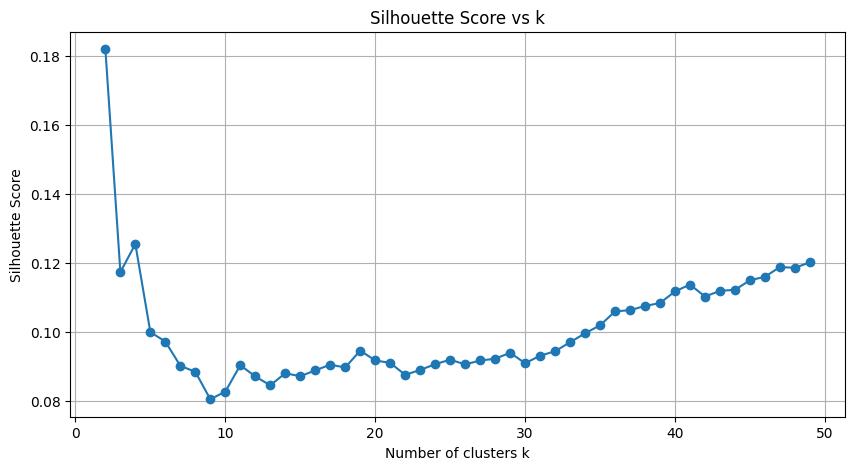

In [28]:
k_range = range(2, 50)
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    labels = km.fit_predict(DATASETS[2])
    silhouettes.append(silhouette_score(DATASETS[2], labels))

plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouettes, marker='o')
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.grid(True)

График не показывает явного локального максимума вблизи **k=24**. Максимум достигается при **k=2**, после чего значение снижается и медленно восстанавливается, примерно, при **k>20**. Это означает, что геометрически данные не образуют 24 чётко выраженных кластера - классы буквы частично перекрываются в пространстве признаков. Но поскольку истинное число классов известно (24), фиксируем `n_clusters`=24 во всех экспериментах.

## Вспомогательные функции

In [29]:
def generate_parameter_combinations(param_grid: dict[str, list]) -> list[dict]:
    keys = param_grid.keys()
    values = param_grid.values()
    return [dict(zip(keys, combo)) for combo in itertools.product(*values)]


def find_best_params(
    estimator: BaseEstimator,
    param_grid: dict[str, list],
    dataset: np.ndarray,
) -> dict[str, any]:
    parameter_combinations = generate_parameter_combinations(param_grid)
    best_score = -1
    best_params = {}
    rows = []

    for params in parameter_combinations:
        model = clone(estimator).set_params(**params)
        predictions = model.fit_predict(dataset)

        model_score = silhouette_score(dataset, predictions)
        rows.append({**params, "Silhouette": model_score})

        if model_score > best_score:
            best_score = model_score
            best_params = params

    df = pd.DataFrame(rows)
    best_idx = df["Silhouette"].idxmax()
    print("Best params for dimension", dataset.shape[1], ":")
    display(df.loc[[best_idx]].style.format({"Silhouette": "{:.4f}"}))

    return best_params


def evaluate_clustering(
    estimator: BaseEstimator,
    param_grid: dict[str, list],
    datasets: list[np.ndarray],
    labels_true: np.ndarray,
) -> None:
    results = []

    for dataset in datasets:
        params = find_best_params(estimator, param_grid, dataset)

        times = []
        best_sil = -1
        best_predictions = None

        for _ in range(REPEATS):
            model = clone(estimator).set_params(**params)

            start = time.perf_counter()
            predictions = model.fit_predict(dataset)
            times.append(time.perf_counter() - start)

            sil = silhouette_score(dataset, predictions)
            if sil > best_sil:
                best_sil = sil
                best_predictions = predictions

        mean_time = np.mean(times)
        conf_interval = stats.t.ppf(0.975, df=len(times) - 1) * stats.sem(times)

        result = {
            "Clusterer": estimator.__class__.__name__,
            "Dimension": dataset.shape[1],
            "Mean time": round(mean_time, 4),
            "Conf interval": round(conf_interval, 4),
            "Silhouette Score": round(best_sil, 4),
            "AMI Score": round(
                adjusted_mutual_info_score(labels_true, best_predictions), 4
            ),
            "Davies-Bouldin Score": round(
                davies_bouldin_score(dataset, best_predictions), 4
            ),
        }
        results.append(result)

    df_results = pd.DataFrame(results)
    df_results.to_csv(RES_PATH, mode="a", header=not RES_PATH.exists(), index=False)

`find_best_params` перебирает все комбинации параметров на конкретном датасете и возвращает конфигурацию с наилучшим `Silhouette Score`.  
`evaluate_clustering` для каждого датасета сначала находит лучшие параметры, затем запускает обучение `REPEATS` раз для надёжного замера времени и вычисляет все три метрики при найденных параметрах.

## Обучение моделей

### Обучение `CustomKMeans`

`CustomKMeans` запускается с фиксированными параметрами - дополнительные гиперпараметры (**tol**, **max_iter**) не перебираются, чтобы сократить время вычислений на не самой быстрой реализации.

In [ ]:
evaluate_clustering(
    estimator=CustomKMeans(n_clusters=24, random_state=RANDOM_STATE),
    param_grid={},
    datasets=DATASETS,
    labels_true=y,
)

Best params for dimension 17 :


,Silhouette
0,0.1239


Best params for dimension 44 :


,Silhouette
0,0.0973


Best params for dimension 77 :


,Silhouette
0,0.0901


Best params for dimension 200 :


,Silhouette
0,0.0810


Best params for dimension 784 :


,Silhouette
0,0.0812


### Обучение **sklearn** `KMeans`

Перебираем **max_iter** и **tol** - параметры критерия остановки. Они определяют точность сходимости и влияют на то, в каком локальном минимуме остановится алгоритм.

In [ ]:
evaluate_clustering(
    estimator=KMeans(n_clusters=24, random_state=RANDOM_STATE),
    param_grid={"max_iter": [300, 400, 500], "tol": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]},
    datasets=DATASETS,
    labels_true=y,
)

Best params for dimension 17 :


,max_iter,tol,Silhouette
3,300,0.001000,0.1290


Best params for dimension 44 :


,max_iter,tol,Silhouette
0,300,0.000001,0.0946


Best params for dimension 77 :


,max_iter,tol,Silhouette
0,300,0.000001,0.0892


Best params for dimension 200 :


,max_iter,tol,Silhouette
4,300,0.010000,0.0860


Best params for dimension 784 :


,max_iter,tol,Silhouette
0,300,0.000001,0.0838


## Обучение `AgglomerativeClustering`

Перебираем **linkage** - метод вычисления расстояния между кластерами при их объединении. **ward** минимизирует дисперсию внутри кластеров, **complete** использует максимальное расстояние между точками кластеров, **average** - среднее, **single** - минимальное.

In [14]:
evaluate_clustering(
    estimator=AgglomerativeClustering(n_clusters=24),
    param_grid={
        "linkage": ["ward", "complete", "average", "single"],
    },
    datasets=DATASETS,
    labels_true=y,
)

Best params for dimension 17 :


,linkage,Silhouette
0,ward,0.0939


Best params for dimension 44 :


,linkage,Silhouette
2,average,0.0878


Best params for dimension 77 :


,linkage,Silhouette
0,ward,0.0712


Best params for dimension 200 :


,linkage,Silhouette
2,average,0.0701


Best params for dimension 784 :


,linkage,Silhouette
2,average,0.0712


## Результаты и сравнение

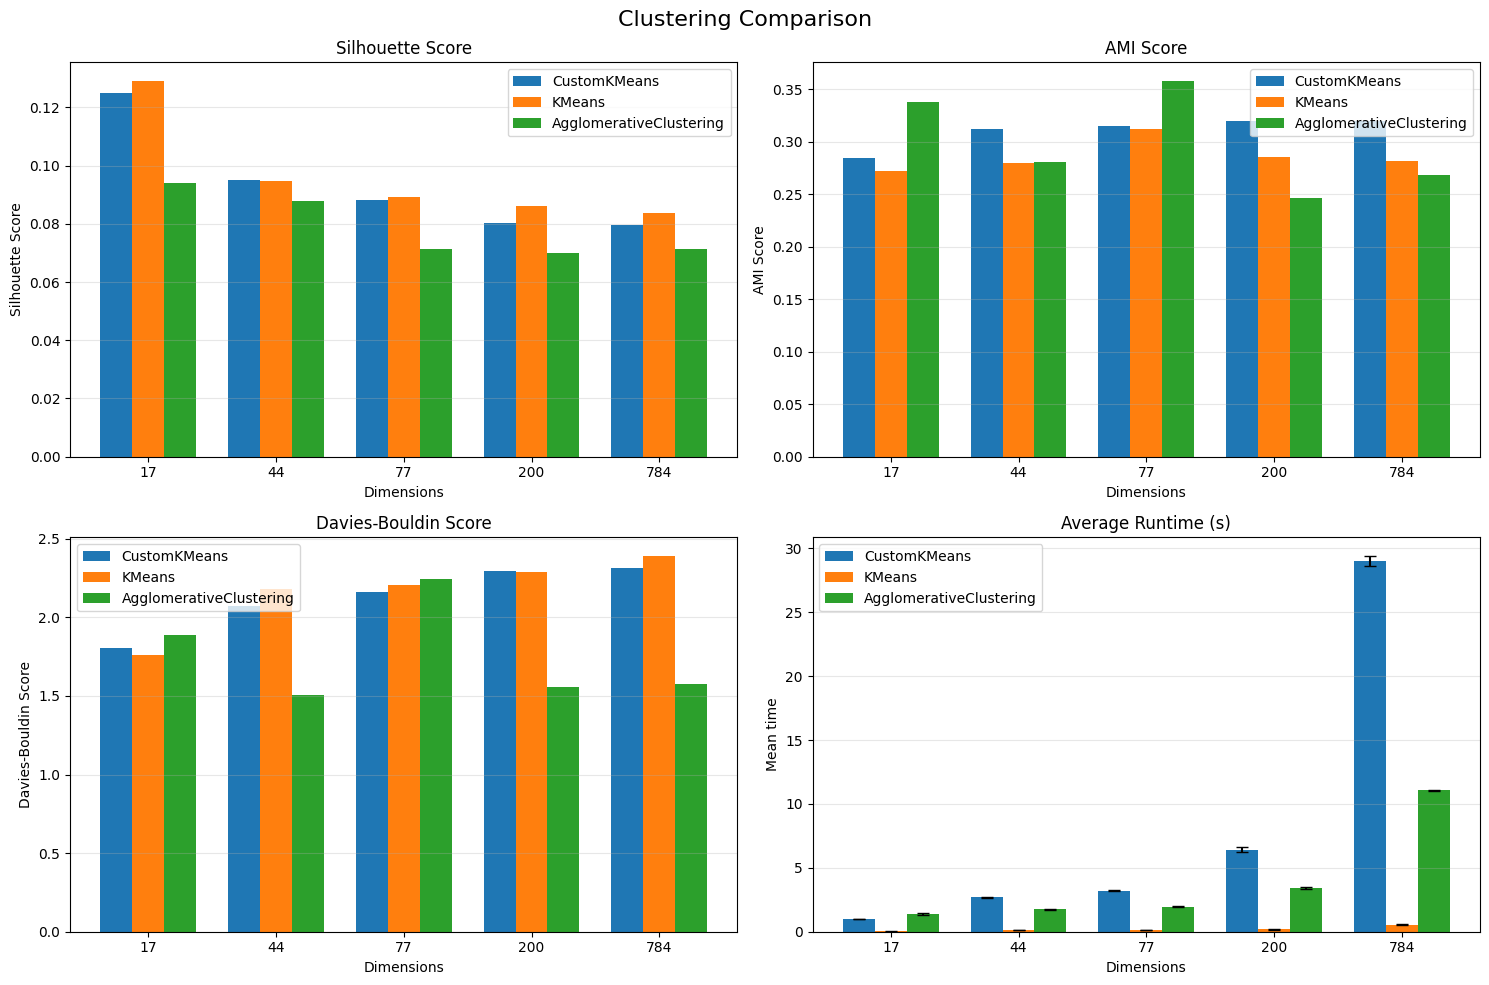

In [15]:
df_plot = pd.read_csv(RES_PATH)

clusterers = df_plot["Clusterer"].unique()
dimensions = df_plot["Dimension"].unique()
x = np.arange(len(dimensions))
width = 0.25

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Clustering Comparison", fontsize=16)

metrics = [
    ("Silhouette Score", "Silhouette Score", True),
    ("AMI Score",        "AMI Score",        True),
    ("Davies-Bouldin Score", "Davies-Bouldin Score", False),
    ("Mean time",        "Average Runtime (s)",  False),
]

for ax, (col, title, _) in zip(axes.flat, metrics):
    for i, clusterer in enumerate(clusterers):
        subset = df_plot[df_plot["Clusterer"] == clusterer].set_index("Dimension").reindex(dimensions)

        yerr = subset["Conf interval"] if col == "Mean time" else None

        ax.bar(
            x + i * width,
            subset[col],
            width=width,
            label=clusterer,
            yerr=yerr,
            capsize=4,
            error_kw={"elinewidth": 1.5, "ecolor": "black"},
        )

    ax.set_title(title)
    ax.set_xlabel("Dimensions")
    ax.set_ylabel(col)
    ax.set_xticks(x + width, dimensions)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

На графиках видны следующие закономерности:

- **Скорость:** **sklearn** `KMeans` значительно быстрее остальных - за счёт оптимизированной реализации и инициализации `k-means++`. `CustomKMeans` работает медленнее при тех же параметрах. С ростом размерности время увеличивается у всех алгоритмов, поэтому снижение размерности через `PCA` может быть важно на практике.

- **`Silhouette Score`:** у всех моделей значения выше при меньшем числе компонент и снижаются с ростом размерности - в высокоразмерном пространстве попарные расстояния становятся более однородными, что затрудняет разделение кластеров. Лучший результат у `KMeans` и `CustomKMeans` при 17 компонентах, причём их значения близки, что подтверждает корректность собственной реализации.

- **`AMI Score`:** лучший результат у `AgglomerativeClustering` при 77 компонентах, то есть иерархическая кластеризация точнее восстанавливает истинные классы при умеренной размерности. `KMeans` и `CustomKMeans` дают близкие значения на всех датасетах.

- **`Davies-Bouldin Score`:** `AgglomerativeClustering` показывает лучшие значения на ряде размерностей, но ведёт себя нестабильно. `KMeans` деградирует плавно и предсказуемо с ростом числа компонент.

Для более детального анализа рассмотрим лучший алгоритм по `AMI` - `AgglomerativeClustering` при 77 компонентах. Сопоставим кластеры с истинными метками и покажем для каждого большого кластера один "истинный" пример и несколько типичных изображений из самого кластера (выбраны как ближайшие к центру).

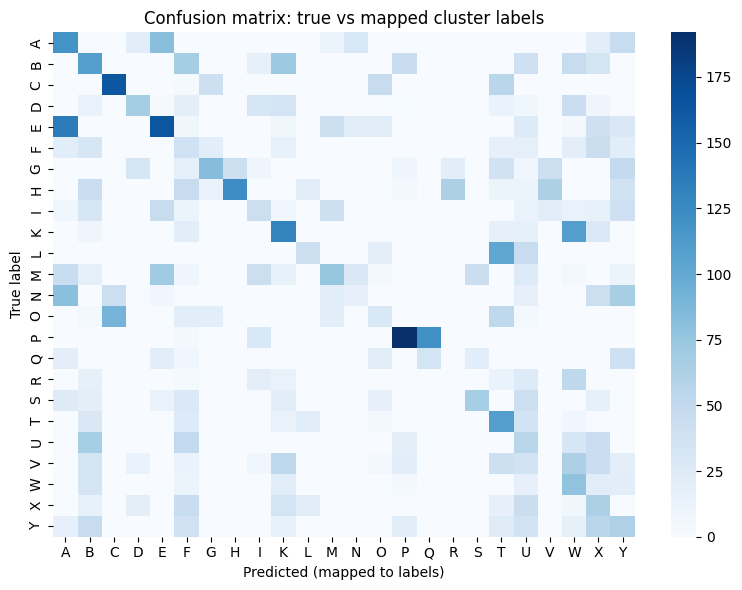

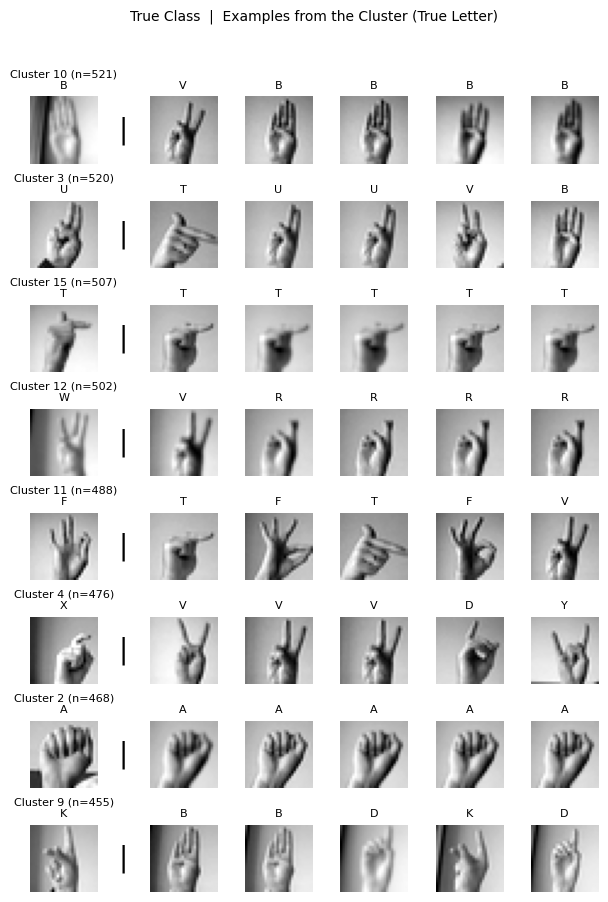

In [ ]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
import seaborn as sns

MAX_CLUSTERS_TO_SHOW = 8
N_EXAMPLES_PER_CLUSTER = 5
DATASET_IDX = 2  # 77 component

clusterer = AgglomerativeClustering(n_clusters=24, linkage="ward")
preds = clusterer.fit_predict(DATASETS[DATASET_IDX])


def map_clusters_to_labels(y_true, y_pred):
    cont = pd.crosstab(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(-cont)
    mapping = {
        cont.columns[col]: int(cont.index[row]) for row, col in zip(row_ind, col_ind)
    }
    mapped = np.array([mapping.get(p, -1) for p in y_pred])
    return mapping, mapped


mapping, mapped_preds = map_clusters_to_labels(y, preds)

# Confusion matrix
cm = confusion_matrix(y, mapped_preds, labels=sorted(y.unique()))
labels_letters = [chr(int(l) + 65) for l in sorted(y.unique())]
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=labels_letters,
    yticklabels=labels_letters,
)
plt.xlabel("Predicted (mapped to labels)")
plt.ylabel("True label")
plt.title("Confusion matrix: true vs mapped cluster labels")
plt.tight_layout()
plt.show()

# Visualization
cluster_counts = pd.Series(preds).value_counts().sort_values(ascending=False)
clusters_to_show = list(cluster_counts.index[:MAX_CLUSTERS_TO_SHOW])
rows = len(clusters_to_show)
cols = 2 + N_EXAMPLES_PER_CLUSTER  # [true image] [sep] [examples...]
fig, axes = plt.subplots(
    rows,
    cols,
    figsize=((1 + 0.1 + N_EXAMPLES_PER_CLUSTER) * 1.0, rows * 1.1),
    gridspec_kw={"width_ratios": [1, 0.1] + [1] * N_EXAMPLES_PER_CLUSTER},
)
if rows == 1:
    axes = np.expand_dims(axes, 0)


def get_image(idx):
    return df.iloc[idx].drop("label").values.reshape(28, 28)


for r, cluster_id in enumerate(clusters_to_show):
    idxs = np.where(preds == cluster_id)[0]
    mapped_label = mapping.get(cluster_id, -1)
    mapped_char = chr(mapped_label + 65) if mapped_label >= 0 else "?"

    # True example
    ax_true = axes[r, 0]
    true_idxs = np.where(y.values == mapped_label)[0]
    if len(true_idxs) > 0:
        ax_true.imshow(get_image(true_idxs[0]), cmap="gray")
    ax_true.set_title(
        f"Cluster {cluster_id} (n={len(idxs)})\n{mapped_char}", fontsize=8
    )
    ax_true.axis("off")

    # Separator
    ax_sep = axes[r, 1]
    ax_sep.text(0.5, 0.5, "|", fontsize=20, ha="center", va="center")
    ax_sep.axis("off")

    if len(idxs) == 0:
        for c in range(2, cols):
            axes[r, c].axis("off")
        continue

    # Cluster examples (nearest to center)
    cluster_points = DATASETS[DATASET_IDX][idxs]
    center = cluster_points.mean(axis=0)
    sel = idxs[
        np.argsort(np.linalg.norm(cluster_points - center, axis=1))[
            :N_EXAMPLES_PER_CLUSTER
        ]
    ]

    for i, idx in enumerate(sel, start=2):
        ax = axes[r, i]
        ax.imshow(get_image(idx), cmap="gray")
        ax.set_title(chr(int(y.iloc[idx]) + 65), fontsize=8)
        ax.axis("off")

plt.suptitle(
    "True Class  |  Examples from the Cluster (True Letter)", fontsize=10, y=1.02
)
plt.tight_layout()

Матрица ошибок показывает, что часть классов выделяется достаточно чётко (заметные тёмные клетки на диагонали), однако многие классы смешиваются (напр., A/E/N, P/Q, C/O) или путаются (напр., M или N), что согласуется с визуальными наблюдениями.  
Визуализация показывает интуитивное представление о внутренности кластеров: наличие разных примеров вблизи центра в одном кластере указывает на неоднозначность данных.

## Выводы

1) `PCA` значительно ускоряет обучение без существенной потери качества. При 44–77 компонентах сохраняется 90–95% дисперсии, а время обучения сокращается в несколько раз.

2) **sklearn** `KMeans` показывает лучший баланс скорости и качества среди рассмотренных алгоритмов.

3) `CustomKMeans` даёт результаты, сопоставимые с **sklearn** `KMeans`, что подтверждает правильность реализации. Разница в скорости объясняется отсутствием оптимизаций.

4) `AgglomerativeClustering` показывает лучший `AMI` при 77 компонентах, точнее восстанавливая истинные классы. Детальный анализ подтверждает: некоторые буквы выделяются достаточно чётко, тогда как визуально похожие жесты смешиваются. Однако работает медленнее и ведёт себя менее предсказуемо при изменении размерности.

5) Абсолютные значения метрик невысоки у всех алгоритмов - датасет объективно сложен для кластеризации. Многие жесты визуально похожи, что подтверждается визуализациями `t-SNE`, графиком `Silhouette vs k`, не имеющим выраженного пика при **k=24**; а также и матрицей ошибок, которая показывает смешение разных классов.